In this notebook, the working mechanism of SN2N will be elaborated.

In [2]:
# import required libraries
import numpy as np
import tifffile 
import tifffile as tiff
import os
from glob import glob
from SelfN2N.SN2N_datagen_RL_sliding_stacknormalize import data_generator
import sys 
import torch
from SelfN2N.selfn2n_nonormalize import SelfN2N
from pathlib import Path
import matplotlib.pyplot as plt
print(torch.cuda.is_available())

True


#### **DATA GENERATION**
First, training data are generated according to all data in the given given data dir. There are parameters mainly related to data augmentation might be adjusted, as explained in [README.md](./README.md) and [official SN2N website](https://github.com/WeisongZhao/SN2N). The default ones, however, may suffice in most cases.

In [3]:
# dir containing your data to be denoised
img_path = Path('./example/rawdata/')

In [19]:
# Default paramter settings, see README.md for detailed descriptions.
P2Pmode = 1
P2Pup = 1
BAmode = 1
SWsize = 64

In [4]:
# create folders
save_folder = img_path / 'generated_data'
os.makedirs(save_folder, exist_ok=True)

left_path = save_folder / 'odd'
right_path = save_folder / 'even'
save_path = save_folder / 'DL_datasets'
test_path = save_folder / 'test_data'
os.makedirs(left_path, exist_ok=True)
os.makedirs(right_path, exist_ok=True)
os.makedirs(save_path, exist_ok=True)
os.makedirs(test_path, exist_ok=True)

In [21]:
# split data along T axis
def split_file(src: Path,even_path,odd_path,test_path):

    print(f'Processing {src.name} ...')
    try:
        with tiff.TiffFile(str(src)) as tif:
            frames = tif.asarray()          
            if frames.ndim == 2:            
                frames = frames[np.newaxis, ...]
    except Exception as e:
        print(f'  ├─ Failed to read {src.name}: {e}', file=sys.stderr)
        return

    first_frame = frames[0]
    test_out = test_path / f'{src.stem}_first.tif'
    tiff.imwrite(str(test_out), first_frame, photometric='minisblack')
    print(f'  ├─ First frame -> {test_out.name}')

    left_frames = frames[0::2]
    right_frames = frames[1::2]   

    if left_frames.size:
        left_out = even_path / f'{src.stem}_left.tif'
        tiff.imwrite(str(left_out), left_frames, photometric='minisblack')
        print(f'  ├─ {left_frames.shape[0]} left frames -> {left_out.name}')
    if right_frames.size:
        right_out = odd_path / f'{src.stem}_right.tif'
        tiff.imwrite(str(right_out), right_frames, photometric='minisblack')
        print(f'  └─ {right_frames.shape[0]} right frames -> {right_out.name}')

In [22]:
# generating training dataset
img_path = Path(img_path)
tif_paths = list(img_path.glob('*.tif')) + list(img_path.glob('*.tiff'))
if not tif_paths:
    print('No .tif or .tiff files found in the given dir!')
for p in tif_paths:
    split_file(p, even_path=left_path, odd_path=right_path, test_path=test_path)

#generate dataset
d = data_generator(img_path_left=left_path, img_path_right=right_path, save_path=save_path, pre_augment_mode=P2Pmode,
                    augment_mode=BAmode, img_res=(128, 128), ifx2=False, inter_method='Fourier', sliding_interval=32)
d.savedata4folder_agument_RL(interval=SWsize, times=P2Pup, roll=1, threshold_mode=2, threshold=0)
print('dataset has been generated')

Processing Substack (1-30).tif ...
  ├─ First frame -> Substack (1-30)_first.tif
  ├─ 15 left frames -> Substack (1-30)_left.tif
  └─ 15 right frames -> Substack (1-30)_right.tif
Processing number 1 frame
Saving training images: 100
Saving training images: 200
Saving training images: 300
Saving training images: 400
Saving training images: 500
Saving training images: 600
Saving training images: 700
Saving training images: 800
Saving training images: 900
Saving training images: 1000
Saving training images: 1100
Saving training images: 1200
Saving training images: 1300
Saving training images: 1400
Saving training images: 1500
Saving training images: 1600
Saving training images: 1700
Saving training images: 1800
Saving training images: 1900
Saving training images: 2000
Saving training images: 2100
Saving training images: 2200
Saving training images: 2300
Saving training images: 2400
Saving training images: 2500
Saving training images: 2600
Saving training images: 2700
Saving training image

Here, we take a look at one generated image pair. 

Text(0.5, 1.0, 'Patches generated by diagonal resampling')

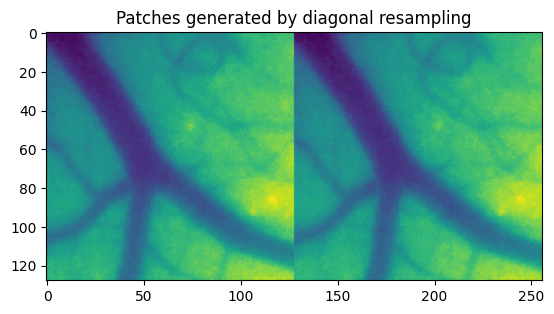

In [23]:
train_data_path = img_path / 'generated_data/DL_datasets'
tif_paths = list(train_data_path.glob('*.tif')) + list(train_data_path.glob('*.tiff'))
im_generated = tiff.imread(tif_paths[1000])
plt.imshow(im_generated)
plt.title('Patches generated by diagonal resampling')

#### **Training**


In [8]:
# Default paramter settings, see README.md for detailed descriptions.
epochs = 50 # usually 50 or 100
lr = 2e-4
bs = 64
test_batch_size = 1
reg = 1.5 # self-constrained learning weight, higher values will give cleaner images, but also higher risk of over-smoothing, a value of 1 will be OK in general cases.

In [25]:
def trainSN2N(datasets_name,epochs,train_batch_size,test_batch_size,lr,reg_sparse,prefix,tests_name,reg,traindata_path,test_path,img_path):
    torch.cuda.empty_cache()
    
    os.makedirs((str(img_path) + ('/images/%s'%(tests_name))), exist_ok=True)
    os.makedirs((str(img_path) + ('/images/%s/weights'%(tests_name))), exist_ok=True)
    os.makedirs((str(img_path) + ('/images/%s/images'%(tests_name))), exist_ok=True)

    sn2nunet = SelfN2N(dataset_name = datasets_name, tests_name = tests_name, reg = reg, reg_sparse = reg_sparse, 
                constrained_type = 'L1',lr=lr, epochs = epochs, train_batch_size = train_batch_size, 
                ifadaptive_lr = False, test_batch_size=test_batch_size,traindata_path=traindata_path,test_path=test_path,img_path=img_path)
    sn2nunet.train()

In [26]:
# set as your desired name
datasets_name = ''
reg_sparse = 0
prefix = 'Neuron_'

tests_name = (prefix + (
        '%s_EPOCH%d_BS%d_LOSSconsis_%.2f_LOSSsparse%.2f_' % (datasets_name, epochs, bs, reg, reg_sparse)))

torch.cuda.empty_cache()
os.makedirs(str(img_path) + '/images/%s' % tests_name, exist_ok=True)
os.makedirs(str(img_path) + '/images/%s/weights' % tests_name, exist_ok=True)
os.makedirs(str(img_path) + '/images/%s/images' % tests_name, exist_ok=True)

sn2nunet = SelfN2N(dataset_name=datasets_name, tests_name=tests_name, reg=reg, reg_sparse=reg_sparse,
                   constrained_type='L1', lr=lr, epochs=epochs, train_batch_size=bs,
                   ifadaptive_lr=False, test_batch_size=test_batch_size, img_path=str(img_path))
sn2nunet.train()
print('Training completed.')

106258
cuda
D:\SN2N\SN2N\rawdata/generated_data/DL_datasets
[Epoch 0/50] [Batch 0/1660] [loss:5.825863] time:0:00:00.808372
[Epoch 0/50] [Batch 100/1660] [loss:5.624613] time:0:00:05.806558
[Epoch 0/50] [Batch 200/1660] [loss:2.805773] time:0:00:10.727895
[Epoch 0/50] [Batch 300/1660] [loss:3.253259] time:0:00:15.555209
[Epoch 0/50] [Batch 400/1660] [loss:1.396675] time:0:00:20.593464
[Epoch 0/50] [Batch 500/1660] [loss:2.192037] time:0:00:25.506492
[Epoch 0/50] [Batch 600/1660] [loss:5.277666] time:0:00:30.344069
[Epoch 0/50] [Batch 700/1660] [loss:5.675203] time:0:00:35.438417
[Epoch 0/50] [Batch 800/1660] [loss:2.939389] time:0:00:40.435794
[Epoch 0/50] [Batch 900/1660] [loss:7.390380] time:0:00:45.427559
[Epoch 0/50] [Batch 1000/1660] [loss:2.524752] time:0:00:51.087106
[Epoch 0/50] [Batch 1100/1660] [loss:2.957720] time:0:00:56.564309
[Epoch 0/50] [Batch 1200/1660] [loss:4.589694] time:0:01:01.590328
[Epoch 0/50] [Batch 1300/1660] [loss:0.634394] time:0:01:06.460981
[Epoch 0/50] [

MemoryError: Unable to allocate 432. MiB for an array with shape (30, 1944, 1944) and data type float32

#### **Inference**

With the trained models, we can denoise the original noisy raw data.

In [6]:
# preidiction function
def predict_(model, img_path, save_path, fname, model_name, ifGPU=True):
    device = torch.device("cuda" if torch.cuda.is_available() and ifGPU else "cpu")
    if isinstance(img_path, str):
        img_path = Path(img_path)
    image_data = imread(str(img_path / fname))
    if image_data.dtype != np.uint8:
        max_val = np.iinfo(image_data.dtype).max
        image_data = (image_data.astype(np.float32) * 255.0 / max_val).clip(0, 255).astype(np.uint8)
    try:
        t, x, y = image_data.shape  
        image_data = image_data/255
        image_data = image_data.astype('float32')
        test_pred_np = np.zeros((t, x, y), dtype=np.float32)
    except ValueError:
        t = 1
        x, y = image_data.shape
        image_data = image_data/255
        image_data = image_data.astype('float32')
        image_data = np.expand_dims(image_data, axis=0)  # 添加帧维度
        test_pred_np = np.zeros((t, x, y), dtype=np.float32)
    for frame in range(t):
        single_frame = image_data[frame, :, :]
        #single_frame = normalize_(single_frame)
        single_frame = single_frame.astype('float32')
        single_frame = single_frame.reshape(1,x,y)
        imsize = (1,1,x,y)
        imagA = np.zeros(imsize)
        imagA[0,:,:,:] = single_frame
        imagA = torch.from_numpy(imagA)
        imagA = imagA.to(device, dtype = torch.float32)
        with torch.no_grad():
            test_pred = model(imagA)
        test_pred = test_pred.to(torch.device("cpu"))
        test_pred = test_pred.numpy()
        #test_pred = normalize_(test_pred)
        #plt.imshow(test_pred[0,0,:,:])
        #plt.show()

        test_pred_np[frame, :, :] = test_pred
        if frame % 100 == 0:
            print('predict %d images'% frame)
    #test_pred_np = normalize_(test_pred_np)

    os.makedirs(save_path, exist_ok=True)
    save_name = os.path.join(save_path, f'_{fname}_{model_name}.tif')
    imwrite(save_name, test_pred_np)
    print(f'Save to {save_name}')

In [11]:
from SelfN2N.AUnet import AUnet
from tifffile import imread, imwrite
# inference
torch.cuda.empty_cache()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

datasets_name = ''
reg_sparse = 0
prefix = 'Neuron_'

tests_name = (prefix + (
        '%s_EPOCH%d_BS%d_LOSSconsis_%.2f_LOSSsparse%.2f_' % (datasets_name, epochs, bs, reg, reg_sparse)))
                            
model_dir = img_path / f'images/{tests_name}/weights/'
print(model_dir)
model_list = sorted(model_dir.glob('*.pth'))
print(len(model_list))
save_dir = img_path / ('images/%s/predictions'% tests_name)

tif_list = sorted(Path(img_path).glob('*.tif'))

if not tif_list or not model_list:
    print('No .tif or .pth found!');

for pth_file in model_list:
    print(f'==== Loading model: {pth_file.name} ====')
    model = AUnet(n_channels=1, n_classes=1, bilinear=True).to(device)
    model.load_state_dict(torch.load(pth_file, map_location=device, weights_only=True))
    model.eval()

    for tif_file in tif_list:
        print(f'  --> infer {tif_file.name}')
        predict_(model, tif_file.parent, save_dir, tif_file.name, pth_file.name, ifGPU=True)

print('All done!')

D:\SN2N\SN2N\rawdata\images\Neuron__EPOCH50_BS64_LOSSconsis_1.50_LOSSsparse0.00_\weights
6
==== Loading model: model_8_29_0.pth ====
  --> infer Substack (1-10).tif
predict 0 images
Save to D:\SN2N\SN2N\rawdata\images\Neuron__EPOCH50_BS64_LOSSconsis_1.50_LOSSsparse0.00_\predictions\_Substack (1-10).tif_model_8_29_0.pth.tif
==== Loading model: model_8_29_10.pth ====
  --> infer Substack (1-10).tif
predict 0 images
Save to D:\SN2N\SN2N\rawdata\images\Neuron__EPOCH50_BS64_LOSSconsis_1.50_LOSSsparse0.00_\predictions\_Substack (1-10).tif_model_8_29_10.pth.tif
==== Loading model: model_8_29_20.pth ====
  --> infer Substack (1-10).tif
predict 0 images
Save to D:\SN2N\SN2N\rawdata\images\Neuron__EPOCH50_BS64_LOSSconsis_1.50_LOSSsparse0.00_\predictions\_Substack (1-10).tif_model_8_29_20.pth.tif
==== Loading model: model_8_29_30.pth ====
  --> infer Substack (1-10).tif
predict 0 images
Save to D:\SN2N\SN2N\rawdata\images\Neuron__EPOCH50_BS64_LOSSconsis_1.50_LOSSsparse0.00_\predictions\_Substack 

Here is a comparison between images before and after SN2N denoising.

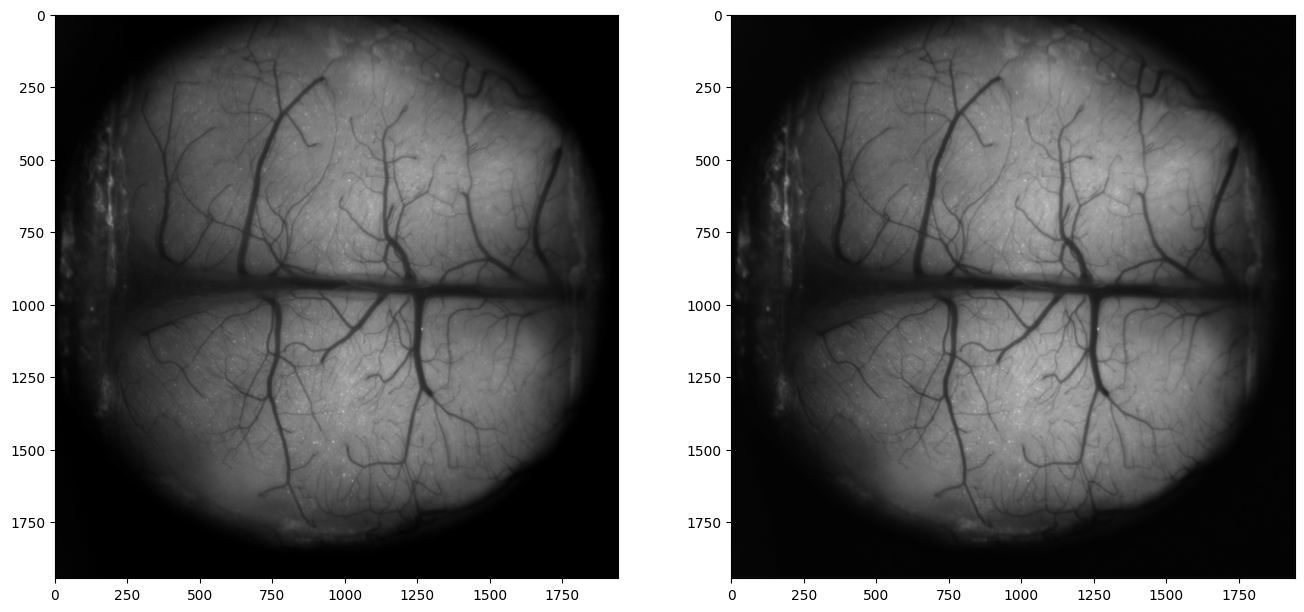

In [16]:
raw_data_paths = list(img_path.glob('*.tif')) + list(img_path.glob('*.tiff'))
im_raw = tiff.imread(raw_data_paths[0])
perdiction_path = img_path / ('images/%s/predictions'% tests_name)
denoised_data_paths = list(perdiction_path.glob('*.tif')) + list(perdiction_path.glob('*.tiff'))
im_denoised = tiff.imread(denoised_data_paths[int(epochs/10-1)])

plt.figure(figsize=(16, 10))
plt.subplot(1, 2, 1)
plt.imshow(im_raw[0], cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(im_denoised[int(epochs/10-1)], cmap='gray')